In [4]:
import numpy as np 
import glob
import os
import astropy.io.fits as fits 
import matplotlib.pyplot as plt 

In [3]:
# folderlist = ['/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/AFLEPNEW/usabledata_NEWREDUCTION/jandata', '/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/AFLEPNEW/usabledata_NEWREDUCTION/octdata']
files410 = glob.glob('/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/HIP65426_newmodel/NEWGOODDATA/onlycalints_nanreplaced/*calints.fits')
savefolder = '/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/HIP65426_newmodel/NEWGOODDATA/DATAFORREAL'
if not os.path.isdir(savefolder):
        os.mkdir(savefolder)
for file in files410:
    obs = fits.open(file)
    filename_current = os.path.basename(file)
    if obs[0].header['FILTER'] == 'F444W':
        if obs[0].header['IS_PSF']:

            name_array = 'reference_'+filename_current[7:10]+'_'+filename_current[20:25]
        else:
            name_array = 'target_'+filename_current[7:10]+'_'+filename_current[20:25]

        folder = os.path.join(savefolder,obs[0].header['TARGPROP'])
        if not os.path.isdir(folder):
            os.mkdir(folder)

        folder = os.path.join(folder,'full_im')
        if not os.path.isdir(folder):
            os.mkdir(folder)

        np.save(os.path.join(folder, name_array), obs[1].data)

        if obs[0].header['IS_PSF']:
            name_array = 'noisemap_reference_'+filename_current[7:10]+'_'+filename_current[20:25]
        else:
            name_array = 'noisemap_target_'+filename_current[7:10]+'_'+filename_current[20:25]

        folder_noise = os.path.join(savefolder,obs[0].header['TARGPROP'],'noise_maps')
        if not os.path.isdir(folder_noise):
            os.mkdir(folder_noise)
        np.save(os.path.join(folder_noise, name_array), obs[2].data)

    # folderlist = ['/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/prepared_14her_obs/formatted_data']
def collapse(arr, csize='all',type='obs'):
    if csize == 'all':
        csize = arr.shape[0]
    num = int(arr.shape[0] / csize)
    collapsed = []
    for i in range(num):
        slice = arr[i*csize:(i+1)*csize]
        if type=='obs':
            print(len(slice), 'is len slice')
            slice = np.mean(slice, axis=0)
        elif type=='noise':
            print(len(slice), 'is len slice')
            slice = np.sqrt(np.sum(slice**2, axis=0)) / len(slice)
        collapsed.append(slice)
    
    return np.array(collapsed)

for folder in [savefolder]:
    targetsfolders = glob.glob(folder+'/*')
    for targetfol in targetsfolders:
        tosave_fullim = targetfol + '/full_im'
        scifiles = glob.glob(tosave_fullim+'/*.npy')
        # tosave = targetfol+'/maybedetectorstuff'
        # if not os.path.isdir(tosave):
        #     os.mkdir(tosave)
        for scifile in scifiles:
            # if 'reference' not in scifile and 'COADDALL' not in scifile:
            scifilecoadded = collapse(np.load(scifile), csize='all', type='obs')
            np.save(os.path.join(tosave_fullim, os.path.basename(scifile)[:-4]+'COADDALL.npy'), scifilecoadded)

        tosave_noisemap = targetfol + '/noise_maps'
        noisefiles = glob.glob(tosave_noisemap+'/*.npy')

        for noisefile in noisefiles:
            # if 'reference' not in noisefile and 'COADDALL' not in noisefile:
            noisefilecoadded = collapse(np.load(noisefile), csize='all', type='noise')
            np.save(os.path.join(tosave_noisemap, os.path.basename(noisefile)[:-4]+'COADDALL.npy'), noisefilecoadded)

2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice
2 is len slice


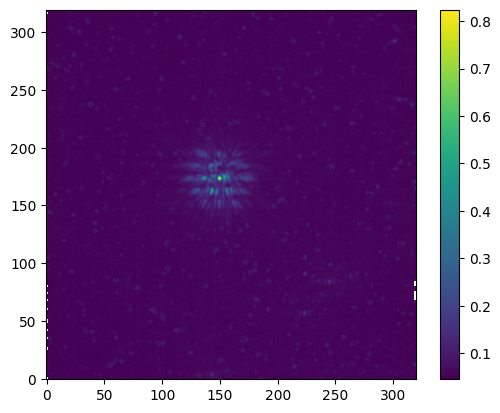

In [6]:
a = np.load('/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/HIP65426_newmodel/NEWGOODDATA/DATAFORREAL/HIP-65426/noise_maps/noisemap_target_002_00001COADDALL.npy')
v = plt.imshow(a[0], origin='lower')
plt.colorbar(v)

In [ ]:
# e = np.load('/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/EllsData/F444WNiceData/2MJ0443/full_im/target_017_00001.npy')
# e.shape

(17, 320, 320)

In [ ]:
# filefits = fits.open('/projects/b1094/rodrigoyeah/optics_jwst/EDDO_repo/EDDO/EllsData/GTO 1184/nanreplaced/jw01184027001_03106_00001_nrcalong_calints.fits')
# filefits[0].header['TARGPROP'], filefits[0].header['DATE-OBS']

('TYC5899', '2023-02-11')

In [ ]:
# LP-944-20 IS 2022-09-06 and sptype M9
# TYC (first obs one roll) is 2022-10-03 and sptype M3
# TYC (second obs with two rolls) is 2023-02-11 and sptype M3